In [1]:
# COLAB SETUP

%cd /content
!rm -rf /content/proto-tsrl
!git clone https://github.com/haiyan-wang/proto-tsrl.git /content/proto-tsrl
%cd /content/proto-tsrl

from google.colab import drive
drive.mount('/content/drive')

import sys
import os

project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

/content
Cloning into '/content/proto-tsrl'...
remote: Enumerating objects: 677, done.
remote: Counting objects: 100% (284/284), done.
remote: Compressing objects: 100% (210/210), done.
remote: Total 677 (delta 167), reused 139 (delta 74), pack-reused 393 (from 1)
Receiving objects: 100% (677/677), 20.50 MiB | 20.17 MiB/s, done.
Resolving deltas: 100% (380/380), done.
/content/proto-tsrl
Mounted at /content/drive
/content/proto-tsrl


In [2]:
!pip install pacmap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 152.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams.update({
    "font.family": "cmr10",
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "axes.unicode_minus": False
})

import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

import pacmap

from src.utils.training_utils import _pairwise_cos_sim, _extended_forward
from src.utils.sampling_utils import TimeSeriesDataset
from src.experiments.synthetic_univariate.univariate_model import UnivariateModel
from src.experiments.ppg.ppg_data_utils import *

In [4]:
# SETTINGS

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# device
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

# data quality
INCLUDE_CLEAN_DATA = True
INCLUDE_SEMINOISY_DATA = True
INCLUDE_NOISY_DATA = False
TRAIN_SET_SIZE = int(1e4)

# logging
SAVE_DIR = "/content/drive/MyDrive/Duke/Senior Year/Thesis/experiments/ppg"

# architecture
REPR_DIMS = [300]
MODELS = {}
for dim in REPR_DIMS:
    model_list = {}

    ckpt_dir = f"{SAVE_DIR}/checkpoints_deep/dim{dim}"
    for ckpt_file in os.listdir(ckpt_dir):
        epoch = ckpt_file[10:-3]
        ckpt = torch.load(f"{ckpt_dir}/{ckpt_file}", map_location = "cpu")
        MODEL = UnivariateModel(representation_dimension = dim)
        MODEL.load_state_dict(ckpt)
        MODEL = MODEL.to(DEVICE)
        if torch.cuda.device_count() > 1:
            MODEL = nn.DataParallel(MODEL)
        MODEL.eval()

        model_list[epoch] = MODEL

    MODELS[dim] = model_list

cuda:0


In [ ]:
# LOAD DATA

X_train, y_train = load_data(
    file_path = '/content/drive/MyDrive/Duke/Senior Year/Thesis/ppg_data/',
    clean = INCLUDE_CLEAN_DATA,
    seminoisy = INCLUDE_SEMINOISY_DATA,
    noisy = INCLUDE_NOISY_DATA,
    dataset = 'train',
    return_labels = True
)
indices = np.random.default_rng(SEED).permutation(X_train.shape[0])
X_train, y_train = X_train[indices][:TRAIN_SET_SIZE], y_train[indices][:TRAIN_SET_SIZE]

X_test, y_test = load_data(
    file_path = '/content/drive/MyDrive/Duke/Senior Year/Thesis/ppg_data/',
    clean = INCLUDE_CLEAN_DATA,
    seminoisy = INCLUDE_SEMINOISY_DATA,
    noisy = INCLUDE_NOISY_DATA,
    dataset = 'test',
    return_labels = True
)

# RESHAPE HERE WHEN collate_fn = None
X_train, X_test = np.transpose(X_train, (0, 2, 1)), np.transpose(X_test, (0, 2, 1))

print(f'X_train shape: {X_train.shape}')
print(f'Train set positive samples: {np.sum(y_train)}')
print(f'X_test shape: {X_test.shape}')
print(f'Test set positive samples: {np.sum(y_test)}')

In [ ]:
# GENERATE REPRESENTATIONS

if not os.path.exists(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-repr-train.csv') or not os.path.exists(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-repr-test.csv'):

    with torch.inference_mode():

        X_train_tensor, X_test_tensor = torch.tensor(X_train, dtype = torch.float32).to(DEVICE), torch.tensor(X_test, dtype = torch.float32).to(DEVICE)

        for dim in REPR_DIMS:
            model = MODELS[dim]['epoch55']
            repr_train, repr_test = model(X_train_tensor), model(X_test_tensor)
            repr_train, repr_test = repr_train.cpu().numpy(), repr_test.cpu().numpy()

            np.savetxt(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-repr-train.csv', repr_train, delimiter = ',')
            np.savetxt(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-repr-test.csv', repr_test, delimiter = ',')

In [ ]:
# LOAD TRAIN AND TEST SET REPRESENTATIONS AND CREATE DATALOADERS

repr = {}
for dim in REPR_DIMS:
    repr[dim] = {}
    for repr_set in ['train', 'test']:
        repr[dim][repr_set] = pd.read_csv(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-repr-{repr_set}.csv', header = None).values

# Convert to tensors
y_tensors = {}
y_tensors['train'] = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)
y_tensors['test'] = torch.tensor(y_test, dtype = torch.float32).unsqueeze(1)

repr_loaders = {}
for dim in REPR_DIMS:
    repr_loaders[dim] = {}
    for repr_set in ['train', 'test']:
        X_tensor = torch.tensor(repr[dim][repr_set], dtype = torch.float32)
        X_dataset = TensorDataset(X_tensor, y_tensors[repr_set])
        if repr_set == 'train':
            repr_loaders[dim][repr_set] = DataLoader(X_dataset, batch_size = 256, shuffle = True)
        else:
            repr_loaders[dim][repr_set] = DataLoader(X_dataset, batch_size = X_tensor.size(0), shuffle = False)

# Classification Tasks

In [ ]:
# SIMPLE MODELS

lr_clf = LogisticRegression(max_iter = 500, random_state = SEED)
dt_clf = DecisionTreeClassifier(min_samples_split = 5)
rf_clf = RandomForestClassifier(n_estimators = 100)

sample_weights = compute_sample_weight(class_weight = "balanced", y = y_train)

for dim in REPR_DIMS:
    print(f'===== {dim} dimensional representations =====')

    df_train, df_test = repr[dim]['train'], repr[dim]['test']
    ss = StandardScaler().fit(df_train)
    df_train, df_test = ss.transform(df_train), ss.transform(df_test)

    lr_clf.fit(df_train, y_train) #, sample_weight = sample_weights)
    dt_clf.fit(df_train, y_train) #, sample_weight = sample_weights)
    rf_clf.fit(df_train, y_train) #, sample_weight = sample_weights)

    y_pred_lr = lr_clf.predict(df_test)
    y_pred_dt = dt_clf.predict(df_test)
    y_pred_rf = rf_clf.predict(df_test)

    acc_lr = accuracy_score(y_test, y_pred_lr)
    acc_dt = accuracy_score(y_test, y_pred_dt)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    print(f'acc_lr = {round(acc_lr, 3)} | acc_dt = {round(acc_dt, 3)} | acc_rf = {round(acc_rf, 3)}')
    print('LR')
    print(confusion_matrix(y_test, y_pred_lr))
    print('DT')
    print(confusion_matrix(y_test, y_pred_dt))
    print('RF')
    print(confusion_matrix(y_test, y_pred_rf))

In [ ]:
# MLP

class mlp_clf(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim*2),
            nn.ReLU(),
            nn.Linear(input_dim*2, input_dim*4),
            nn.ReLU(),
            nn.Linear(input_dim*4, input_dim*2),
            nn.ReLU(),
            nn.Linear(input_dim*2, 1)
        )

    def forward(self, x):
        return self.net(x)  # logits

def mlpclf_train(
        model,
        dataloader,
        device,
        criterion,
        optimizer,
        n_epochs,
        log_interval = 10
    ):

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)

        if (epoch+1) % log_interval == 0:
            print(f"Epoch {epoch+1:02d}/{n_epochs} - Train Loss: {epoch_loss:.4f}")

def mlpclf_eval(
        model,
        dataloader,
        device
    ):

    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits)

            preds = (probs >= 0.5).float()

            all_probs.extend(probs.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_targets.extend(yb.numpy().ravel())

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    print(f"Accuracy          : {accuracy_score(all_targets, all_preds):.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(all_targets, all_preds))

In [ ]:
mlps = {}
opts = {}
for dim in REPR_DIMS:
    mlps[dim] = mlp_clf(input_dim = dim).to(DEVICE)
    opts[dim] = torch.optim.Adam(mlps[dim].parameters(), lr = 1e-3)

n_neg, n_pos = np.sum(y_train == 0), np.sum(y_train == 1)
pos_weight = torch.tensor([n_neg / n_pos], dtype = torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss() # pos_weight = pos_weight)

In [ ]:
for dim in REPR_DIMS:
    print(f'===== {dim}D =====')
    mlpclf_train(
        model = mlps[dim],
        dataloader = repr_loaders[dim]['train'],
        device = DEVICE,
        criterion = criterion,
        optimizer = opts[dim],
        n_epochs = dim
    )

In [ ]:
for dim in REPR_DIMS:
    print(f'===== {dim}D =====')
    mlpclf_eval(
    model = mlps[dim],
    dataloader = repr_loaders[dim]['test'],
    device = DEVICE
)

# Prototype Evolution

In [ ]:
@torch.no_grad()
def prototype_evolution(dim, n_prototype_layers):

    epoch_sims = [[] for _ in range(n_prototype_layers)]

    for epoch, m in MODELS[dim].items():
        if isinstance(m, nn.DataParallel):
            model = m.module
        else:
            model = m

        epoch_num = int(epoch[5:])

        for layer_idx, prototype_layer in enumerate(model.prototype_layers):
            prototype_vectors = prototype_layer.prototype_vectors
            sim = _pairwise_cos_sim(prototype_vectors, prototype_vectors, eps = 1e-8)

            n = sim.size(0)
            if n < 2:
                return sim.new_tensor(0.0)

            off_diag_mask = ~torch.eye(n, dtype = torch.bool, device = sim.device)
            off_diag = sim[off_diag_mask]
            epoch_sims[layer_idx].append(off_diag.mean().cpu())

    return epoch_sims

fig, axs = plt.subplots(1, len(REPR_DIMS), figsize = (5*len(REPR_DIMS), 5), tight_layout = True)

for i, dim in enumerate(REPR_DIMS):
    sims = prototype_evolution(dim, 4)
    colors = ['blue', 'red', 'green', 'purple']

    for layer_idx, layer_sims in enumerate(sims):
        axs[i].plot(layer_sims, color = colors[layer_idx], label = f'Prototype Layer {layer_idx + 1}')

    axs[i].set_title(f'Pairwise Prototype Similarity ({dim}D)')
    axs[i].set_xlabel('Epoch')
    axs[i].set_ylabel('Average Pairwise Similarity')
    axs[i].legend(loc = 'upper right')

# Dimension Reduced Intermediate Representations

In [ ]:
dr_epochs = [35, 40, 45, 50, 55]

X_test_tensor = torch.tensor(X_test, dtype = torch.float32).to(DEVICE)

with torch.inference_mode():
    for dim in REPR_DIMS:
        for epoch in dr_epochs:
            model = MODELS[dim][f'epoch{epoch}']
            repr_test = model(X_test_tensor).cpu().numpy()
            np.savetxt(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-epoch{epoch}-repr-test.csv', repr_test, delimiter = ',')

In [ ]:
embs = {}

pm = pacmap.PaCMAP(n_components = 3)
for dim in REPR_DIMS:
    embs[dim] = {}
    for epoch in dr_epochs:
        repr = pd.read_csv(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-epoch{epoch}-repr-test.csv', header = None)
        emb = pm.fit_transform(repr)
        embs[dim][epoch] = emb

In [ ]:
fig, axs = plt.subplots(
    1, 5,
    figsize = (25, 5),
    tight_layout = True,
    subplot_kw = {"projection": "3d"}
)

fig.suptitle("3D PaCMAP Embeddings of Learned PPG Signal Representations", fontsize = 20, y = 1)

class_colors = ['blue', 'red']
class_labels = ["NSR", "AFib"]

for dim in REPR_DIMS:
    for col, epoch in enumerate(dr_epochs):
        emb = embs[dim][epoch]
        ax = axs[col]

        for class_value in range(2):
            ax.scatter(
                emb[:, 0][y_test == class_value],
                emb[:, 1][y_test == class_value],
                emb[:, 2][y_test == class_value],
                s = 5,
                c = class_colors[class_value],
                label = class_labels[class_value]
            )

        ax.set_title(f"Epoch {epoch}", fontsize=16)

legend_handles = [
    Line2D(
        [0], [0],
        marker = 'o',
        linestyle = 'None',
        color = class_colors[i],
        markersize = 8,
        label = class_labels[i]
    )
    for i in range(2)
]

fig.legend(
    handles = legend_handles,
    loc = 'upper center',
    bbox_to_anchor = (0.5, 0.955),
    ncol = 2,
    frameon = True,
    fontsize = 14
)

fig.tight_layout(rect = [0, 0, 1, 0.88])

In [ ]:
fig, axs = plt.subplots(
    1, 5,
    figsize = (25, 5),
    tight_layout = True
)

fig.suptitle(
    "2D PaCMAP Embeddings of Learned PPG Signal Representations", fontsize = 20, y = 0.98)

class_colors = ['blue', 'red']
class_labels = ["NSR", "AFib"]

for dim in REPR_DIMS:
    for col, epoch in enumerate(dr_epochs):
        emb = embs[dim][epoch]
        ax = axs[col]

        for class_value in range(2):
            ax.scatter(
                emb[:, 0][y_test == class_value],
                emb[:, 1][y_test == class_value],
                s = 5,
                c = [class_colors[class_value]],
                label = class_labels[class_value]
            )

        ax.set_title(f"Epoch {epoch}", fontsize = 16)

legend_handles = [
    Line2D(
        [0], [0],
        marker = 'o',
        linestyle = 'None',
        color = class_colors[i],
        markersize = 8,
        label = class_labels[i]
    )
    for i in range(2)
]

fig.legend(
    handles = legend_handles,
    loc = 'upper center',
    bbox_to_anchor = (0.5, 0.935),
    ncol = 2,
    frameon = True,
    fontsize = 14
)

fig.tight_layout(rect = [0, 0, 1, 0.91])

# Activation Maps

In [ ]:
# Reload test data to avoid wait time

X_test, y_test = load_data(
    file_path = '/content/drive/MyDrive/Duke/Senior Year/Thesis/ppg_data/',
    clean = INCLUDE_CLEAN_DATA,
    seminoisy = INCLUDE_SEMINOISY_DATA,
    noisy = INCLUDE_NOISY_DATA,
    dataset = 'test',
    return_labels = True
)

X_test = np.transpose(X_test, (0, 2, 1))
X_test_tensor = torch.tensor(X_test, dtype = torch.float32)

m = MODELS[dim]['epoch55']
if isinstance(m, nn.DataParallel):
    model = m.module
else:
    model = m

In [ ]:
@torch.no_grad()
def get_prototype_activations(model, x, device):

    model.eval()
    x = x.to(device)
    out = _extended_forward(model, x)

    return out["a"]

@torch.no_grad()
def overlay_prototype_activation(model, x, proto_layer_idx, proto_idx, device, label):

    acts = get_prototype_activations(model, x, device)
    a = acts[proto_layer_idx][0, proto_idx]

    signal = x[0, 0].detach().cpu()
    T = signal.shape[0]

    a_up = F.interpolate(a[None, None, :], size = T, mode = "linear", align_corners = False)[0, 0].cpu() # upsample activation trace to raw signal length
    a_up = (a_up - a_up.min()) / (a_up.max() - a_up.min() + 1e-8) # normalize for display

    fig, ax = plt.subplots(figsize = (9, 3))

    ymin = signal.min().item() - 0.05
    ymax = signal.max().item() + 0.05

    # 1-row heatmap stretched across the full signal height
    heat = a_up.numpy()[None, :]
    im = ax.imshow(
        heat,
        aspect = "auto",
        extent = [0, T - 1, ymin, ymax],
        origin = "lower",
        cmap = 'jet',
        alpha = 0.4,
    )

    cbar = fig.colorbar(im, ax = ax, pad = 0.02)
    cbar.set_label("Normalized Prototype Activation")

    ax.plot(signal.numpy(), linewidth = 1.0, color = 'black')
    ax.set_xlim(0, T - 1)
    ax.set_ylim(ymin, ymax)
    if label == 0:
        ax.set_title(f"Prototype ({proto_layer_idx + 1}, {proto_idx}) Activations: NSR")
    elif label == 1:
        ax.set_title(f"Prototype ({proto_layer_idx + 1}, {proto_idx}) Activations: AFib")

    plt.show()

/tmp/ipykernel_2951/168209857.py:22: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize = (9, 3))
/tmp/ipykernel_2951/168209857.py:38: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  cbar = fig.colorbar(im, ax = ax, pad = 0.02)


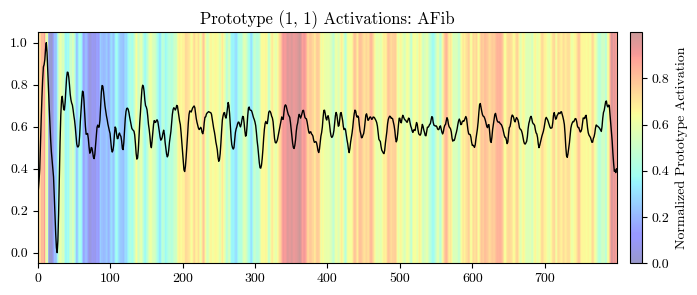

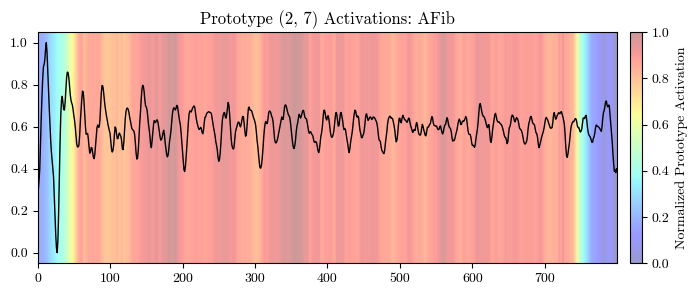

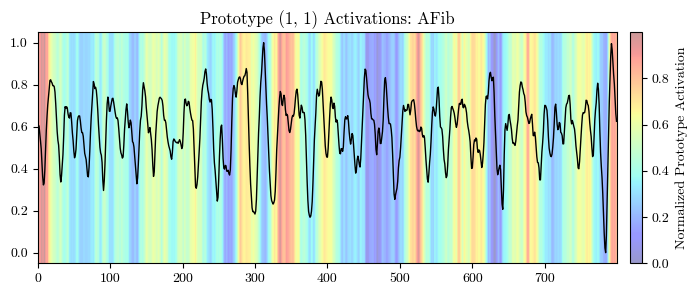

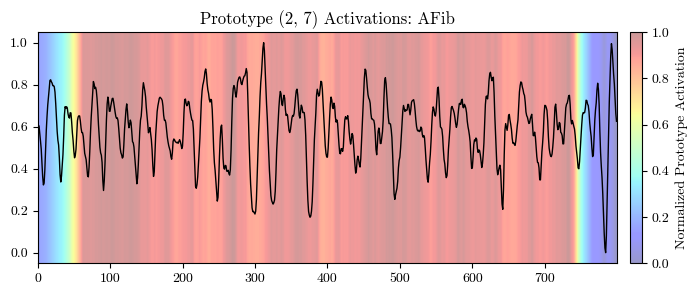

In [ ]:
for proto_layer_idx in range(len(model.prototype_layers)):
    for proto_idx in range(model.prototype_layers[proto_layer_idx].prototype_vectors.size(0)):
        overlay_prototype_activation(model, X_test_tensor[0], proto_layer_idx, proto_idx, DEVICE, 0)

/tmp/ipykernel_2951/168209857.py:22: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize = (9, 3))
/tmp/ipykernel_2951/168209857.py:38: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  cbar = fig.colorbar(im, ax = ax, pad = 0.02)


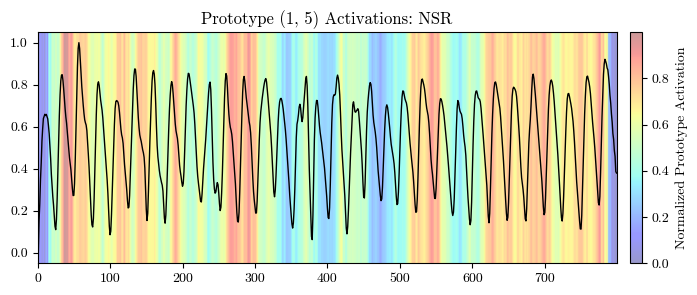

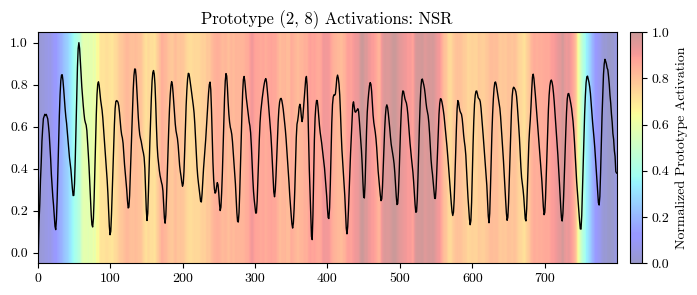

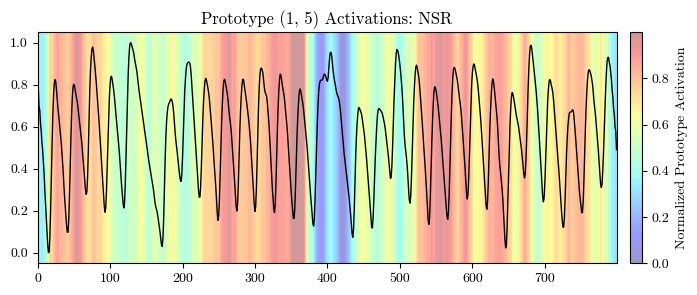

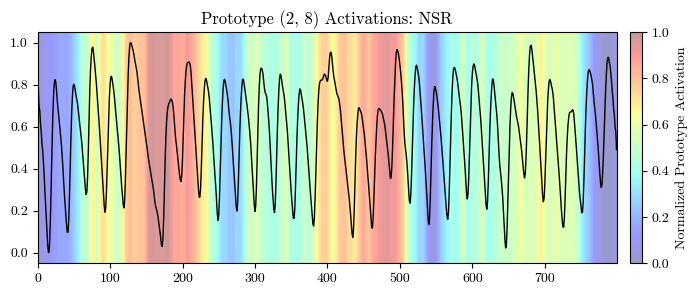

In [ ]:
for proto_layer_idx in range(len(model.prototype_layers)):
    for proto_idx in range(model.prototype_layers[proto_layer_idx].prototype_vectors.size(0)):
        overlay_prototype_activation(model, X_test_tensor[-1], proto_layer_idx, proto_idx, DEVICE, 1)